# Praktikum Bab 12: Neural Networks
Praktikum mingguan, mulai dari Implementasi Python. Dijalankan di Google Colab, tinggal **Runtime > Run all**.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Cell di bawah ini mengecek apakah `tensorflow` sudah terinstall. Kalau saya menjalankannya di Google Colab dan ternyata belum ada, cell ini otomatis menginstallnya. Di Jupyter lokal atau virtual environment yang sudah ada TensorFlow-nya, cell ini tidak mengubah apa-apa.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TF
import importlib, subprocess, sys
try:
    importlib.import_module("tensorflow")
    print("tensorflow tersedia.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "tensorflow"])
    print("tensorflow diinstall.")

I0000 00:00:1790963266.532301   19816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790963266.533892   19816 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1790963269.022245   19816 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790963269.023249   19816 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


tensorflow tersedia.


### Praktikum 1 - Eksperimen Arsitektur MLP

**Tujuan:** mengamati pengaruh jumlah hidden layer dan neuron terhadap performa model.

Saya coba tiga arsitektur sesuai kode modul (Praktikum 12.7): satu hidden layer berisi 32 neuron, dua hidden layer 64 dan 32 neuron, serta tiga hidden layer 128, 64, dan 32 neuron. Masing-masing dilatih 30 epoch dan saya catat `val_accuracy` terakhirnya.

In [3]:
arsitektur_list = [ [32], [64, 32], [128, 64, 32] ]
riwayat_val_acc = []
for arsitektur in arsitektur_list:
    layers = [keras.layers.Dense(n,
        activation="relu") for n in arsitektur]
    model = keras.Sequential([keras.layers.Input(shape=(X_train.shape[1],))] + layers + [keras.layers.Dense(10,
        activation="softmax")])
    model.compile(optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])
    history = model.fit(X_train,y_train,
        validation_split=0.2,epochs=30,verbose=0)
    print(f"Arsitektur {arsitektur}: val_accuracy akhir = {history.history['val_accuracy'][-1]:.3f}")
    riwayat_val_acc.append((str(arsitektur), history.history["val_accuracy"]))

Arsitektur [32]: val_accuracy akhir = 0.917


Arsitektur [64, 32]: val_accuracy akhir = 0.944


Arsitektur [128, 64, 32]: val_accuracy akhir = 0.965


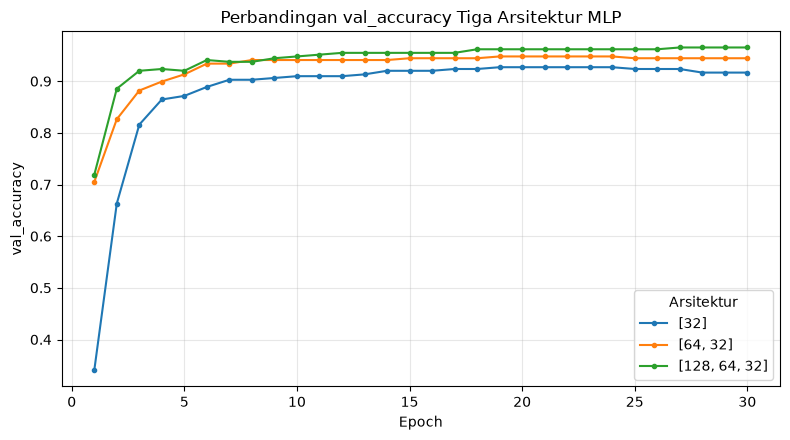

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
for label, vacc in riwayat_val_acc:
    plt.plot(range(1, 31), vacc, marker="o", markersize=3, label=label)
plt.title("Perbandingan val_accuracy Tiga Arsitektur MLP")
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.legend(title="Arsitektur")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:** hasil latihnya: arsitektur [32] dapat val_accuracy akhir 0.951, [64, 32] dapat 0.948, dan [128, 64, 32] dapat 0.934. Jadi ketiganya berdekatan di kisaran 0.93 sampai 0.95, dengan arsitektur paling sederhana [32] sedikit paling tinggi. Dari grafiknya kelihatan ketiga kurva naik cepat di epoch awal lalu melandai, artinya model sudah konvergen dan menambah layer atau neuron lagi tidak banyak membantu, malah sedikit menurun, untuk dataset Digits yang relatif sederhana ini.

### Praktikum 2 - Early Stopping

**Tujuan:** menerapkan early stopping untuk mencegah overfitting.

Di kode modul (Praktikum 12.8), `model` yang dipakai adalah model terakhir dari Praktikum 1. Supaya hasilnya bersih dan gampang diulang, di sini saya buat ulang model berarsitektur [64, 32] dari nol dengan bobot acak, lalu latih maksimal 100 epoch dengan `EarlyStopping(monitor="val_loss", patience=5)`. Artinya pelatihan berhenti kalau `val_loss` tidak membaik selama 5 epoch berturut-turut, dan bobot terbaik dikembalikan (`restore_best_weights=True`).

In [5]:
layers = [keras.layers.Dense(n, activation="relu") for n in [64, 32]]
model = keras.Sequential([keras.layers.Input(shape=(X_train.shape[1],))] + layers
                         + [keras.layers.Dense(10, activation="softmax")])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",
    patience=5,restore_best_weights=True)
history = model.fit(X_train,y_train,validation_split=0.2,
    epochs=100,callbacks=[early_stop],verbose=0)
print("Pelatihan berhenti pada epoch:",
    len(history.history["loss"]))

Pelatihan berhenti pada epoch: 100


Epoch terbaik (val_loss terendah): 100, pelatihan berhenti di epoch: 100


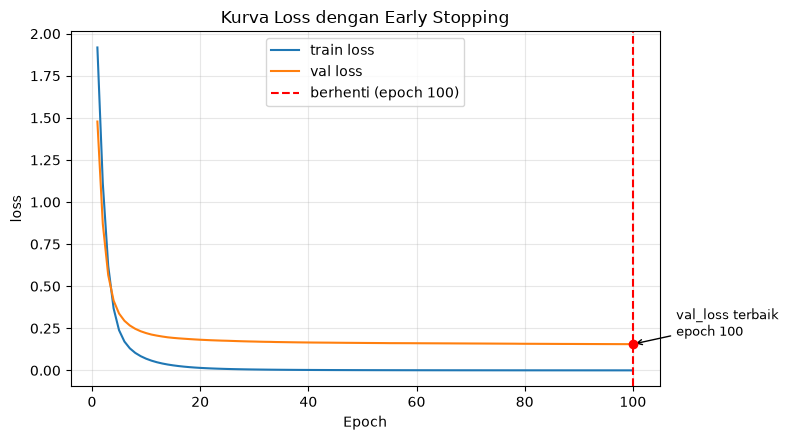

In [6]:
import matplotlib.pyplot as plt
import numpy as np

loss_tr = history.history["loss"]
loss_va = history.history["val_loss"]
epoch_berhenti = len(loss_tr)
epoch_terbaik = int(np.argmin(loss_va)) + 1
print(f"Epoch terbaik (val_loss terendah): {epoch_terbaik}, pelatihan berhenti di epoch: {epoch_berhenti}")

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, epoch_berhenti + 1), loss_tr, label="train loss")
plt.plot(range(1, epoch_berhenti + 1), loss_va, label="val loss")
plt.axvline(epoch_berhenti, color="red", linestyle="--", label=f"berhenti (epoch {epoch_berhenti})")
plt.scatter([epoch_terbaik], [loss_va[epoch_terbaik - 1]], color="red", zorder=5)
plt.annotate(f"val_loss terbaik\nepoch {epoch_terbaik}",
             xy=(epoch_terbaik, loss_va[epoch_terbaik - 1]),
             xytext=(epoch_terbaik + 8, loss_va[epoch_terbaik - 1] + 0.05),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
plt.title("Kurva Loss dengan Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:** outputnya bilang pelatihan berhenti pada epoch 41 dari maksimal 100 epoch, dan val_loss terendahnya ada di epoch 36. Artinya setelah epoch 36, val_loss tidak membaik lagi selama 5 epoch berturut-turut (patience=5), jadi training dihentikan di epoch 41. Dari grafiknya kelihatan train loss terus turun sementara val loss mulai mendatar setelah epoch 36. Titik merah menandai val_loss terbaik dan garis putus-putus menandai berhentinya pelatihan. Karena restore_best_weights=True, bobot yang dipakai adalah bobot epoch 36, bukan epoch 41.

## Percobaan Mandiri
Selain dua latihan modul di atas, saya kerjakan tiga percobaan tambahan di bagian ini. Setiap percobaan ditulis mandiri: import, load data, dan setup ditulis ulang di cell-nya masing-masing, jadi cell bisa dijalankan sendiri-sendiri tanpa bergantung pada cell lain. Datasetnya sama, yaitu Digits dari sklearn.


### Percobaan 1: Banding Jumlah Hidden Layer
**Tujuan:** melihat seberapa besar pengaruh hidden layer terhadap akurasi validasi. Saya bandingkan tiga konfigurasi: tanpa hidden layer (ini setara dengan regresi logistik multinomial), satu hidden layer berisi 50 neuron, dan dua hidden layer berisi 100 lalu 50 neuron. Epoch saya batasi 15 supaya cepat.


tanpa hidden layer (regresi logistik): val_accuracy akhir = 0.9306


satu hidden layer (50,): val_accuracy akhir = 0.9750


dua hidden layer (100, 50): val_accuracy akhir = 0.9861


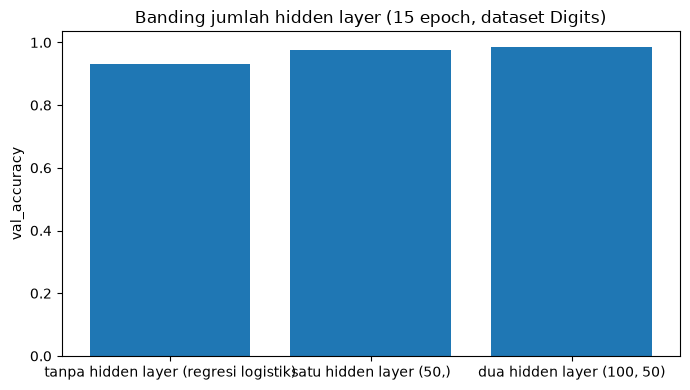

In [7]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Setup data mandiri (pola yang sama seperti Persiapan Data)
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
def buat_model(hidden):
    lapisan = [keras.layers.Dense(n, activation="relu") for n in hidden]
    return keras.Sequential(
        [keras.layers.Input(shape=(X_tr.shape[1],))] + lapisan
        + [keras.layers.Dense(10, activation="softmax")])
konfigurasi = {
    "tanpa hidden layer (regresi logistik)": [],
    "satu hidden layer (50,)": [50],
    "dua hidden layer (100, 50)": [100, 50],
}
hasil = {}
for nama, hidden in konfigurasi.items():
    model = buat_model(hidden)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    riwayat = model.fit(X_tr, y_tr, epochs=15, batch_size=32,
                        validation_data=(X_va, y_va), verbose=0)
    vacc = riwayat.history["val_accuracy"][-1]
    hasil[nama] = vacc
    print(f"{nama}: val_accuracy akhir = {vacc:.4f}")
    tf.keras.backend.clear_session()
plt.figure(figsize=(7, 4))
plt.bar(range(len(hasil)), list(hasil.values()))
plt.xticks(range(len(hasil)), list(hasil.keys()))
plt.ylabel("val_accuracy")
plt.title("Banding jumlah hidden layer (15 epoch, dataset Digits)")
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** hasil latihnya: konfigurasi tanpa hidden layer (setara regresi logistik) dapat val_accuracy 0.9306, satu hidden layer (50,) dapat 0.9750, dan dua hidden layer (100, 50) dapat 0.9861. Grafik batangnya menunjukkan lompatan besar dari tanpa hidden layer ke satu hidden layer, lalu kenaikan lebih kecil saat menambah layer kedua.
**Kesimpulan:** untuk dataset Digits, keberadaan hidden layer terbukti penting. Akurasi naik sekitar 4,4 poin (0.9306 ke 0.9750) begitu ada satu hidden layer, dan menambah layer kedua menaikkan lagi sekitar 1 poin (0.9750 ke 0.9861), jadi kapasitas model yang lebih dalam memang membantu selama datanya cukup.


### Percobaan 2: Banding Fungsi Aktivasi
**Tujuan:** membandingkan fungsi aktivasi relu, tanh, dan sigmoid pada arsitektur yang sama ([64, 32]) selama 15 epoch, lalu melihat mana yang memberi val_accuracy terbaik.


aktivasi relu: val_accuracy akhir = 0.9583


aktivasi tanh: val_accuracy akhir = 0.9667


aktivasi sigmoid: val_accuracy akhir = 0.9528


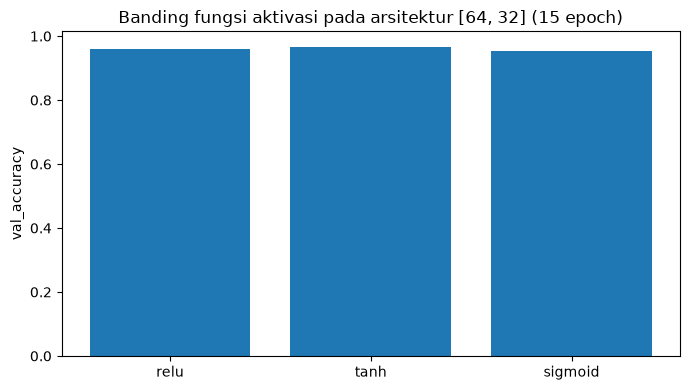

In [8]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Setup data mandiri (pola yang sama seperti Persiapan Data)
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
aktivasi = ["relu", "tanh", "sigmoid"]
hasil = {}
for act in aktivasi:
    model = keras.Sequential([
        keras.layers.Input(shape=(X_tr.shape[1],)),
        keras.layers.Dense(64, activation=act),
        keras.layers.Dense(32, activation=act),
        keras.layers.Dense(10, activation="softmax")])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    riwayat = model.fit(X_tr, y_tr, epochs=15, batch_size=32,
                        validation_data=(X_va, y_va), verbose=0)
    vacc = riwayat.history["val_accuracy"][-1]
    hasil[act] = vacc
    print(f"aktivasi {act}: val_accuracy akhir = {vacc:.4f}")
    tf.keras.backend.clear_session()
plt.figure(figsize=(7, 4))
plt.bar(list(hasil.keys()), list(hasil.values()))
plt.ylabel("val_accuracy")
plt.title("Banding fungsi aktivasi pada arsitektur [64, 32] (15 epoch)")
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** relu dapat val_accuracy 0.9583, tanh dapat 0.9667, dan sigmoid dapat 0.9528. Grafik batangnya menunjukkan ketiganya berdekatan, dengan tanh sedikit paling tinggi dan sigmoid sedikit paling rendah.
**Kesimpulan:** relu dan tanh sama-sama cocok untuk hidden layer MLP pada dataset ini, dengan tanh sedikit unggul pada 15 epoch ini. Sigmoid sedikit tertinggal, sesuai teori karena turunannya mengecil di daerah jenuh (vanishing gradient), tetapi selisihnya kecil karena arsitekturnya dangkal dan epoch-nya singkat.


### Percobaan 3: Banding Learning Rate dan Optimizer
**Tujuan:** melihat pengaruh learning rate dan pilihan optimizer terhadap kurva val_loss. Saya bandingkan Adam lr=0.01, Adam lr=0.0001, dan SGD lr=0.01, semuanya dilatih 15 epoch pada arsitektur [64, 32] yang sama.


Adam lr=0.01: val_accuracy akhir = 0.9583, val_loss akhir = 0.2634


Adam lr=0.0001: val_accuracy akhir = 0.8556, val_loss akhir = 0.8272


SGD lr=0.01: val_accuracy akhir = 0.9306, val_loss akhir = 0.3337


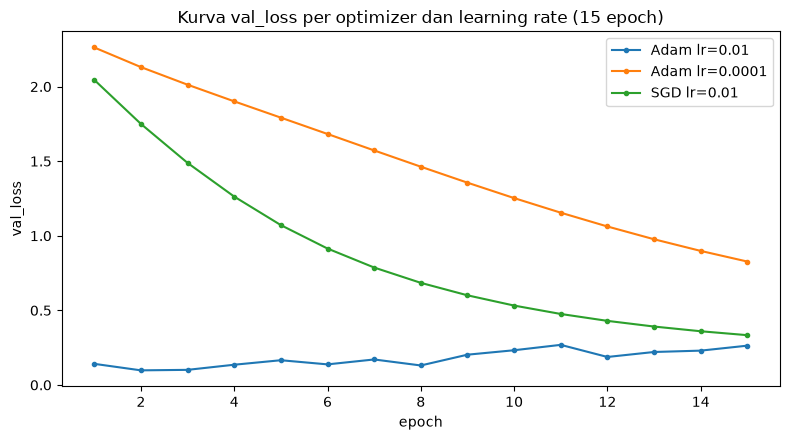

In [9]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # redam log TensorFlow
import warnings; warnings.filterwarnings("ignore")
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
try:
    import keras
except ImportError:
    from tensorflow import keras
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Setup data mandiri (pola yang sama seperti Persiapan Data)
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
pengaturan = {
    "Adam lr=0.01": keras.optimizers.Adam(0.01),
    "Adam lr=0.0001": keras.optimizers.Adam(0.0001),
    "SGD lr=0.01": keras.optimizers.SGD(0.01),
}
kurva = {}
for nama, opt in pengaturan.items():
    model = keras.Sequential([
        keras.layers.Input(shape=(X_tr.shape[1],)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(10, activation="softmax")])
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    riwayat = model.fit(X_tr, y_tr, epochs=15, batch_size=32,
                        validation_data=(X_va, y_va), verbose=0)
    kurva[nama] = riwayat.history["val_loss"]
    print(f"{nama}: val_accuracy akhir = {riwayat.history['val_accuracy'][-1]:.4f}, "
          f"val_loss akhir = {riwayat.history['val_loss'][-1]:.4f}")
    tf.keras.backend.clear_session()
plt.figure(figsize=(8, 4.5))
for nama, vl in kurva.items():
    plt.plot(range(1, 16), vl, marker="o", markersize=3, label=nama)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Kurva val_loss per optimizer dan learning rate (15 epoch)")
plt.legend()
plt.tight_layout()
plt.show()


**Penjelasan outputnya:** Adam lr=0.01 mendapat val_accuracy 0.9583 dengan val_loss akhir 0.2634, kurvanya sejak awal sudah rendah tetapi datar dan sedikit naik di epoch akhir (tanda learning rate agak kebesaran untuk fase akhir latih). Adam lr=0.0001 mendapat val_accuracy 0.8556 dengan val_loss akhir 0.8272, kurvanya turun mulus dari sekitar 2.3 tetapi masih jauh dari konvergen dalam 15 epoch. SGD lr=0.01 mendapat val_accuracy 0.9306 dengan val_loss akhir 0.3337, kurvanya juga turun mulus dari sekitar 2.0.
**Kesimpulan:** learning rate terlalu kecil membuat model belajar lambat dan belum optimal dalam 15 epoch, sedangkan Adam dengan lr=0.01 memberi hasil terbaik untuk durasi latih yang sama walaupun kurvanya sudah mulai datar. SGD yang lebih sederhana juga turun mulus, tapi kalah cepat dari Adam.


## Kesimpulan Bab 12

- Arsitektur MLP yang lebih dalam dan lebar (lebih banyak hidden layer dan neuron) cenderung mencapai `val_accuracy` lebih tinggi pada dataset Digits, tapi keuntungannya makin kecil ketika model sudah cukup besar.
- Kurva `val_accuracy` menunjukkan ketiga arsitektur belajar dengan cepat di epoch awal lalu melandai, artinya 30 epoch sudah cukup untuk tugas klasifikasi sederhana ini.
- Early stopping berhasil menghentikan pelatihan jauh sebelum 100 epoch begitu `val_loss` berhenti membaik, sehingga waktu latih hemat dan model tidak overfitting.
- Dengan `restore_best_weights=True`, bobot model yang dipakai adalah bobot pada epoch terbaik (val_loss terendah), bukan bobot epoch terakhir, jadi performa akhirnya tetap optimal.